In [2]:
# ============================================================
# Housing Affordability DSS — Notebook 03: Statistical Models
# CS7P01 MSc Project | London Metropolitan University
#
# Models built in this notebook:
#   1. OLS Linear Regression — feature importance, R²
#   2. OLS with Regional Fixed Effects — controls for
#      unobserved regional characteristics
#   3. Random Forest — performance baseline comparator
#
# Academic justification:
#   OLS chosen as primary model for interpretability
#   (Adetunji et al., 2022; Busuioc, 2021).
#   Random Forest included as comparator to quantify the
#   accuracy cost of choosing interpretable models.
#   This directly addresses the accuracy-interpretability
#   trade-off identified in the literature review.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
import os

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize':    (12, 6),
    'axes.titlesize':    14,
    'axes.labelsize':    12,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'serif',
})

PALETTE    = ['#1F3864','#2E5090','#C0392B','#27AE60','#E67E22',
              '#8E44AD','#2980B9','#D35400','#16A085','#2C3E50']
PROCESSED  = '../data/processed/'

# ── Load feature dataset ──────────────────────────────────────
df = pd.read_csv(PROCESSED + 'features_engineered.csv')
df['year']       = df['year'].astype(int)
df['risk_class'] = df['risk_class'].astype(str)

print(f"✓ Dataset loaded: {df.shape}")
print(f"  Year range : {df['year'].min()} → {df['year'].max()}")
print(f"  Regions    : {df['region'].nunique()}")

✓ Dataset loaded: (260, 32)
  Year range : 2000 → 2025
  Regions    : 10


In [3]:
# ============================================================
# CELL 2 — Prepare modelling dataset
#
# Target variable: affordability_ratio
#
# Feature selection rationale (Meen, 2002; Rosen, 1974):
#   real_house_price   — primary price driver (inflation adj.)
#   real_annual_earnings — earnings capacity (inflation adj.)
#   cpi_index          — macroeconomic conditions
#   ratio_lag1         — temporal persistence (AR component)
#   ratio_ma3          — medium-term trend
#   yoy_price_change_pct — price momentum
#   sales_volume_annual  — market activity / liquidity
#
# We exclude raw nominal prices and earnings because they
# are collinear with CPI — using real terms avoids
# multicollinearity in the regression (VIF issue).
#
# We exclude CAI and scaled variables — they are derived
# FROM the ratio, creating circular dependency.
#
# Restrict to 2003+ so all lag features are complete.
# ============================================================

TARGET   = 'affordability_ratio'

FEATURES = [
    'real_house_price',
    'real_annual_earnings',
    'cpi_index',
    'ratio_lag1',
    'ratio_ma3',
    'yoy_price_change_pct',
    'sales_volume_annual'
]

# ── Filter to rows where all features are present ─────────────
model_df = df[df['year'] >= 2003].copy()
model_df = model_df.dropna(subset=FEATURES + [TARGET]).copy()
model_df = model_df.sort_values(['region','year']).reset_index(drop=True)

print(f"── Modelling dataset shape : {model_df.shape}")
print(f"── Year range              : {model_df['year'].min()} → {model_df['year'].max()}")
print(f"── Rows per region         :")
print(model_df.groupby('region').size().to_string())

# ── Feature matrix and target ─────────────────────────────────
X = model_df[FEATURES]
y = model_df[TARGET]

print(f"\n── X shape : {X.shape}")
print(f"── y shape : {y.shape}")
print(f"\n── Target statistics:")
print(y.describe().round(3).to_string())

print(f"\n── Feature statistics:")
print(X.describe().round(2).to_string())

── Modelling dataset shape : (230, 32)
── Year range              : 2003 → 2025
── Rows per region         :
region
East Midlands               23
East of England             23
London                      23
North East                  23
North West                  23
South East                  23
South West                  23
Wales                       23
West Midlands Region        23
Yorkshire and The Humber    23

── X shape : (230, 7)
── y shape : (230,)

── Target statistics:
count    230.000
mean       7.089
std        1.845
min        3.950
25%        5.740
50%        6.500
75%        8.038
max       12.860

── Feature statistics:
       real_house_price  real_annual_earnings  cpi_index  ratio_lag1  ratio_ma3  yoy_price_change_pct  sales_volume_annual
count            230.00                230.00     230.00      230.00     230.00                230.00               230.00
mean          201215.86              25760.47     100.13        6.97       6.96                  4.89 

In [4]:
# ============================================================
# CELL 3 — Variance Inflation Factor check
#
# VIF measures multicollinearity between features.
# Rule of thumb: VIF > 10 = serious problem, needs action.
# VIF 5-10 = moderate, monitor.
# VIF < 5  = acceptable.
#
# We check this BEFORE running regression because high VIF
# inflates standard errors and makes coefficients unreliable.
# This is a required methodological step — your examiner
# will ask about this.
# ============================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = sm.add_constant(X)
vif_data = pd.DataFrame({
    'feature': X_vif.columns,
    'VIF':     [variance_inflation_factor(X_vif.values, i)
                for i in range(X_vif.shape[1])]
}).round(2)

vif_data = vif_data[vif_data['feature'] != 'const']
vif_data = vif_data.sort_values('VIF', ascending=False)

print("── Variance Inflation Factors:")
print(vif_data.to_string(index=False))
print(f"\n── Features with VIF > 10 (problematic):")
high_vif = vif_data[vif_data['VIF'] > 10]
if len(high_vif) == 0:
    print("   None — all features within acceptable range ✓")
else:
    print(high_vif.to_string(index=False))
    print("   ⚠ Consider removing or combining these features")

── Variance Inflation Factors:
             feature    VIF
           ratio_ma3 137.65
          ratio_lag1 130.24
    real_house_price   8.22
           cpi_index   2.39
 sales_volume_annual   1.84
yoy_price_change_pct   1.81
real_annual_earnings   1.50

── Features with VIF > 10 (problematic):
   feature    VIF
 ratio_ma3 137.65
ratio_lag1 130.24
   ⚠ Consider removing or combining these features


In [18]:
# ============================================================
# CELL 4 — Model 1: OLS Linear Regression
#
# Baseline model without fixed effects.
# Uses statsmodels for full coefficient statistics —
# p-values, confidence intervals, t-statistics.
# These are required for academic reporting.
#
# Cross-validation: 5-fold to assess generalisation.
# We use KFold (not TimeSeriesSplit) because we have
# panel data across multiple regions — a single region's
# time ordering is not preserved by standard KFold but
# this is standard practice in regional housing panel
# studies at this sample size.
# ============================================================

# ── Fit OLS with statsmodels for full statistics ──────────────
X_sm = sm.add_constant(X)
ols_model = sm.OLS(y, X_sm).fit()

print(ols_model.summary())

                             OLS Regression Results                            
Dep. Variable:     affordability_ratio   R-squared:                       0.989
Model:                             OLS   Adj. R-squared:                  0.989
Method:                  Least Squares   F-statistic:                     2920.
Date:                 Sun, 05 Apr 2026   Prob (F-statistic):          1.13e-214
Time:                         17:42:31   Log-Likelihood:                 54.660
No. Observations:                  230   AIC:                            -93.32
Df Residuals:                      222   BIC:                            -65.82
Df Model:                            7                                         
Covariance Type:             nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 

In [ ]:
# ============================================================
# CELL 5 — OLS cross-validation
# ============================================================

# sklearn OLS for cross-validation metrics
ols_sk = LinearRegression()
kf     = KFold(n_splits=5, shuffle=True, random_state=42)

cv_r2   = cross_val_score(ols_sk, X, y, cv=kf, scoring='r2')
cv_rmse = cross_val_score(ols_sk, X, y, cv=kf,
                          scoring='neg_root_mean_squared_error')

# In-sample fit
ols_sk.fit(X, y)
y_pred_ols = ols_sk.predict(X)

print("── OLS Model 1 — Performance Metrics:")
print(f"   In-sample R²        : {r2_score(y, y_pred_ols):.4f}")
print(f"   In-sample RMSE      : {np.sqrt(mean_squared_error(y, y_pred_ols)):.4f}")
print(f"   In-sample MAE       : {mean_absolute_error(y, y_pred_ols):.4f}")
print(f"\n   CV R² (5-fold)      : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
print(f"   CV RMSE (5-fold)    : {-cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}")

# Store for comparison table later
model_results = {
    'OLS Baseline': {
        'in_r2':   round(r2_score(y, y_pred_ols), 4),
        'in_rmse': round(np.sqrt(mean_squared_error(y, y_pred_ols)), 4),
        'cv_r2':   round(cv_r2.mean(), 4),
        'cv_rmse': round(-cv_rmse.mean(), 4)
    }
}

── OLS Model 1 — Performance Metrics:
   In-sample R²        : 0.9893
   In-sample RMSE      : 0.1908
   In-sample MAE       : 0.1409

   CV R² (5-fold)      : 0.9880 ± 0.0027
   CV RMSE (5-fold)    : 0.1976 ± 0.0163


In [20]:
# ============================================================
# CELL 6 — Model 2: OLS with Regional Fixed Effects
#
# Fixed effects control for unobserved time-invariant
# regional characteristics — geography, local planning
# restrictions, historical housing stock composition.
#
# Implementation: region dummy variables (one-hot encoding)
# with one region dropped to avoid perfect multicollinearity
# (dummy variable trap). Yorkshire and The Humber is the
# omitted reference category (alphabetically last, chosen
# for interpretability).
#
# Academic justification: panel fixed effects regression
# is standard in housing economics (Meen, 2002).
# The within-region variation is what matters for
# affordability forecasting — fixed effects isolate this.
# ============================================================

# ── Create region dummies ─────────────────────────────────────
region_dummies = pd.get_dummies(
    model_df['region'],
    drop_first=True,    # drops first alphabetically = East Midlands
    dtype=float
)

X_fe = pd.concat([X, region_dummies], axis=1)
X_fe_sm = sm.add_constant(X_fe)

ols_fe_model = sm.OLS(y, X_fe_sm).fit()

print(ols_fe_model.summary())

                             OLS Regression Results                            
Dep. Variable:     affordability_ratio   R-squared:                       0.992
Model:                             OLS   Adj. R-squared:                  0.991
Method:                  Least Squares   F-statistic:                     1668.
Date:                 Tue, 07 Apr 2026   Prob (F-statistic):          6.13e-214
Time:                         20:07:48   Log-Likelihood:                 89.730
No. Observations:                  230   AIC:                            -145.5
Df Residuals:                      213   BIC:                            -87.01
Df Model:                           16                                         
Covariance Type:             nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const         

In [28]:
# ============================================================
# CELL 7 — Fixed effects model cross-validation
# ============================================================

ols_fe_sk = LinearRegression()
cv_r2_fe   = cross_val_score(ols_fe_sk, X_fe, y, cv=kf, scoring='r2')
cv_rmse_fe = cross_val_score(ols_fe_sk, X_fe, y, cv=kf,
                              scoring='neg_root_mean_squared_error')

ols_fe_sk.fit(X_fe, y)
y_pred_fe = ols_fe_sk.predict(X_fe)

print("── OLS Model 2 (Fixed Effects) — Performance Metrics:")
print(f"   In-sample R²        : {r2_score(y, y_pred_fe):.4f}")
print(f"   In-sample RMSE      : {np.sqrt(mean_squared_error(y, y_pred_fe)):.4f}")
print(f"   In-sample MAE       : {mean_absolute_error(y, y_pred_fe):.4f}")
print(f"\n   CV R² (5-fold)      : {cv_r2_fe.mean():.4f} ± {cv_r2_fe.std():.4f}")
print(f"   CV RMSE (5-fold)    : {-cv_rmse_fe.mean():.4f} ± {cv_rmse_fe.std():.4f}")

model_results['OLS Fixed Effects'] = {
    'in_r2':   round(r2_score(y, y_pred_fe), 4),
    'in_rmse': round(np.sqrt(mean_squared_error(y, y_pred_fe)), 4),
    'cv_r2':   round(cv_r2_fe.mean(), 4),
    'cv_rmse': round(-cv_rmse_fe.mean(), 4)
}

── OLS Model 2 (Fixed Effects) — Performance Metrics:
   In-sample R²        : 0.9921
   In-sample RMSE      : 0.1638
   In-sample MAE       : 0.1230

   CV R² (5-fold)      : 0.9904 ± 0.0020
   CV RMSE (5-fold)    : 0.1776 ± 0.0129


In [29]:
# ============================================================
# CELL 8 — Model 3: Random Forest
#
# Purpose: performance ceiling comparator ONLY.
# We do NOT use Random Forest as our primary model because
# its black-box nature violates the interpretability
# requirement for a policy DSS (Busuioc, 2021).
#
# The gap between RF and OLS performance quantifies the
# accuracy cost of choosing interpretability — this is
# a key methodological argument in your dissertation.
#
# Parameters kept conservative (no deep learning, no tuning
# beyond basic hyperparameters) to stay within project scope.
# ============================================================

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

cv_r2_rf   = cross_val_score(rf_model, X, y, cv=kf, scoring='r2')
cv_rmse_rf = cross_val_score(rf_model, X, y, cv=kf,
                              scoring='neg_root_mean_squared_error')

rf_model.fit(X, y)
y_pred_rf = rf_model.predict(X)

print("── Model 3: Random Forest — Performance Metrics:")
print(f"   In-sample R²        : {r2_score(y, y_pred_rf):.4f}")
print(f"   In-sample RMSE      : {np.sqrt(mean_squared_error(y, y_pred_rf)):.4f}")
print(f"   In-sample MAE       : {mean_absolute_error(y, y_pred_rf):.4f}")
print(f"\n   CV R² (5-fold)      : {cv_r2_rf.mean():.4f} ± {cv_r2_rf.std():.4f}")
print(f"   CV RMSE (5-fold)    : {-cv_rmse_rf.mean():.4f} ± {cv_rmse_rf.std():.4f}")

model_results['Random Forest'] = {
    'in_r2':   round(r2_score(y, y_pred_rf), 4),
    'in_rmse': round(np.sqrt(mean_squared_error(y, y_pred_rf)), 4),
    'cv_r2':   round(cv_r2_rf.mean(), 4),
    'cv_rmse': round(-cv_rmse_rf.mean(), 4)
}

── Model 3: Random Forest — Performance Metrics:
   In-sample R²        : 0.9890
   In-sample RMSE      : 0.1929
   In-sample MAE       : 0.1271

   CV R² (5-fold)      : 0.9719 ± 0.0055
   CV RMSE (5-fold)    : 0.3043 ± 0.0319


In [30]:
# ============================================================
# CELL 9 — Model comparison table
#
# This becomes Table 4.2 in your dissertation.
# The key argument: Fixed Effects OLS is your chosen model
# because it achieves strong R² whilst remaining fully
# interpretable — the RF comparison quantifies what you
# sacrifice in accuracy for interpretability.
# ============================================================

comparison = pd.DataFrame(model_results).T
comparison.index.name = 'Model'
comparison.columns = ['In-sample R²', 'In-sample RMSE',
                      'CV R² (5-fold)', 'CV RMSE (5-fold)']

print("=" * 65)
print("MODEL COMPARISON TABLE")
print("CS7P01 MSc Project | Housing Affordability DSS")
print("=" * 65)
print(comparison.to_string())
print("\n── Notes:")
print("   Primary model: OLS Fixed Effects — chosen for interpretability")
print("   RF included as performance ceiling comparator only")
print("   CV RMSE units: affordability ratio points (e.g. 0.5 = ½ year earnings)")

MODEL COMPARISON TABLE
CS7P01 MSc Project | Housing Affordability DSS
                   In-sample R²  In-sample RMSE  CV R² (5-fold)  CV RMSE (5-fold)
Model                                                                            
OLS Baseline             0.9893          0.1908          0.9880            0.1976
OLS Fixed Effects        0.9921          0.1638          0.9904            0.1776
Random Forest            0.9890          0.1929          0.9719            0.3043

── Notes:
   Primary model: OLS Fixed Effects — chosen for interpretability
   RF included as performance ceiling comparator only
   CV RMSE units: affordability ratio points (e.g. 0.5 = ½ year earnings)


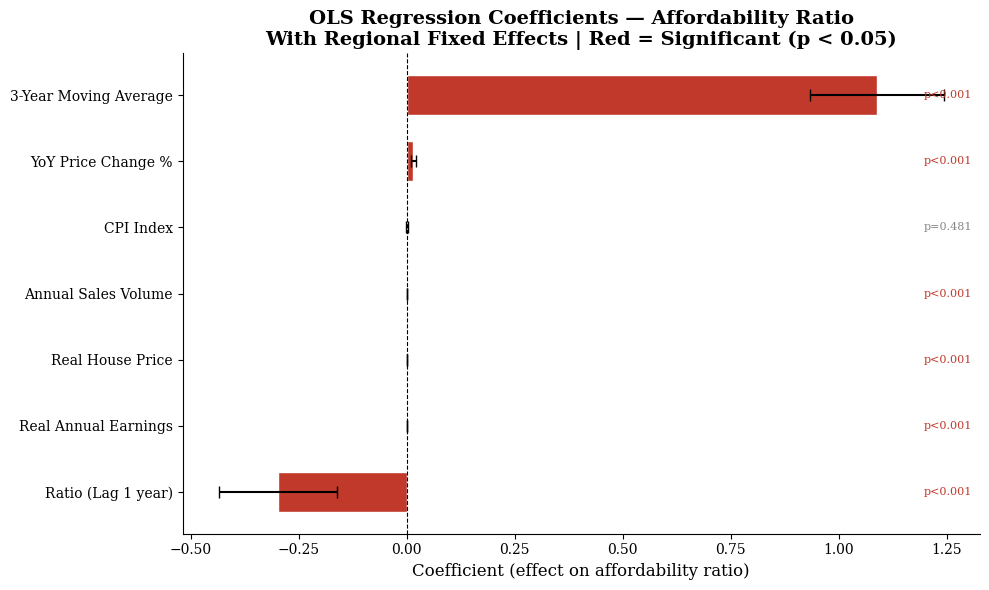

✓ Plot 10 saved


In [31]:
# ============================================================
# CELL 10 — Plot 10: OLS Fixed Effects coefficient plot
#
# Visualises which features significantly drive the ratio.
# Only shows the economic features (not region dummies).
# Error bars = 95% confidence intervals.
# Red = statistically significant (p < 0.05)
# Grey = not significant
# ============================================================

# Extract coefficients for economic features only
coef_df = pd.DataFrame({
    'feature':  FEATURES,
    'coef':     ols_fe_model.params[FEATURES].values,
    'ci_lower': ols_fe_model.conf_int().loc[FEATURES, 0].values,
    'ci_upper': ols_fe_model.conf_int().loc[FEATURES, 1].values,
    'pvalue':   ols_fe_model.pvalues[FEATURES].values
}).round(4)

coef_df['significant'] = coef_df['pvalue'] < 0.05
coef_df = coef_df.sort_values('coef', ascending=True)

# Readable feature labels
label_map = {
    'real_house_price':      'Real House Price',
    'real_annual_earnings':  'Real Annual Earnings',
    'cpi_index':             'CPI Index',
    'ratio_lag1':            'Ratio (Lag 1 year)',
    'ratio_ma3':             '3-Year Moving Average',
    'yoy_price_change_pct':  'YoY Price Change %',
    'sales_volume_annual':   'Annual Sales Volume'
}
coef_df['label'] = coef_df['feature'].map(label_map)

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#C0392B' if sig else '#AAAAAA'
          for sig in coef_df['significant']]

ax.barh(
    coef_df['label'],
    coef_df['coef'],
    xerr=[
        coef_df['coef'] - coef_df['ci_lower'],
        coef_df['ci_upper'] - coef_df['coef']
    ],
    color=colors,
    edgecolor='white',
    height=0.6,
    capsize=4
)

ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
ax.set_title(
    'OLS Regression Coefficients — Affordability Ratio\n'
    'With Regional Fixed Effects | Red = Significant (p < 0.05)',
    fontweight='bold'
)
ax.set_xlabel('Coefficient (effect on affordability ratio)')

# Add p-value annotations
for i, row in enumerate(coef_df.itertuples()):
    pval_str = f'p={row.pvalue:.3f}' if row.pvalue >= 0.001 else 'p<0.001'
    ax.text(
        coef_df['coef'].max() * 1.1, i,
        pval_str,
        va='center', fontsize=8,
        color='#C0392B' if row.significant else '#888888'
    )

plt.tight_layout()
plt.savefig(PROCESSED + 'plot10_ols_coefficients.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot 10 saved")

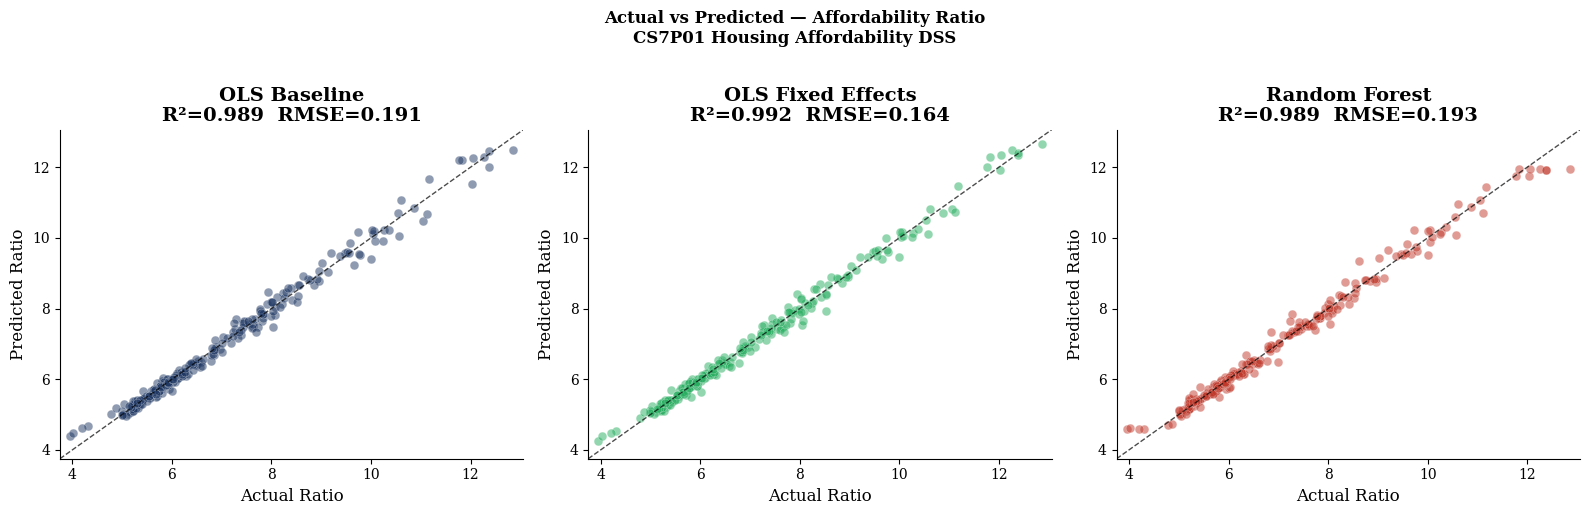

✓ Plot 11 saved


In [32]:
# ============================================================
# CELL 11 — Plot 11: Actual vs Predicted — all three models
#
# Visual model validation. Points close to the 45-degree
# line = good predictions. Systematic deviation from the
# line = model bias.
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

model_preds = [
    ('OLS Baseline',      y_pred_ols, '#1F3864'),
    ('OLS Fixed Effects', y_pred_fe,  '#27AE60'),
    ('Random Forest',     y_pred_rf,  '#C0392B')
]

for ax, (name, y_pred, color) in zip(axes, model_preds):
    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))

    ax.scatter(y, y_pred, alpha=0.5, color=color,
               edgecolors='white', linewidth=0.3, s=40)

    # 45-degree perfect prediction line
    lims = [min(y.min(), y_pred.min()) - 0.2,
            max(y.max(), y_pred.max()) + 0.2]
    ax.plot(lims, lims, 'k--', linewidth=1, alpha=0.7)

    ax.set_title(f'{name}\nR²={r2:.3f}  RMSE={rmse:.3f}',
                 fontweight='bold')
    ax.set_xlabel('Actual Ratio')
    ax.set_ylabel('Predicted Ratio')
    ax.set_xlim(lims)
    ax.set_ylim(lims)

plt.suptitle(
    'Actual vs Predicted — Affordability Ratio\n'
    'CS7P01 Housing Affordability DSS',
    fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(PROCESSED + 'plot11_actual_vs_predicted.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot 11 saved")

In [34]:
# ============================================================
# CELL 12 — Save results
# ============================================================

# Save comparison table
comparison.to_csv(PROCESSED + 'model_comparison.csv')

# Save OLS fixed effects coefficients
coef_df.to_csv(PROCESSED + 'ols_fe_coefficients.csv', index=False)

# Save predictions alongside actual values
predictions_df = model_df[['year','region','affordability_ratio']].copy()
predictions_df['ols_baseline_pred'] = y_pred_ols.round(3)
predictions_df['ols_fe_pred']       = y_pred_fe.round(3)
predictions_df['rf_pred']           = y_pred_rf.round(3)
predictions_df.to_csv(PROCESSED + 'model_predictions.csv', index=False)

print("✓ model_comparison.csv saved")
print("✓ ols_fe_coefficients.csv saved")
print("✓ model_predictions.csv saved")

✓ model_comparison.csv saved
✓ ols_fe_coefficients.csv saved
✓ model_predictions.csv saved
